# Framingham Heart Study - Classification ML Assignment

## Import Libraries

In [1]:
# Basic libraries for data handling
import pandas as pd
import numpy as np

# Libraries for plotting/charts
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# Library to balance imbalanced dataset
from imblearn.over_sampling import SMOTE

# Just for nicer looking charts
sns.set_style("whitegrid")
%matplotlib inline


## Load Dataset

In [2]:
df = pd.read_csv("framingham.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Data Info

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
df.describe()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Check Missing Values

In [5]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing %": missing_percent})
missing_df[missing_df["Missing Count"] > 0]


,Missing Count,Missing %
education,105,2.477584
cigsPerDay,29,0.684285
BPMeds,53,1.250590
totChol,50,1.179802
BMI,19,0.448325
heartRate,1,0.023596
glucose,388,9.155262


## Fill Null Values

In [6]:
# Get list of columns that have missing values
cols_with_null = df.columns[df.isnull().any()]

# Fill each missing value with the median of that column
for col in cols_with_null:
    df[col] = df[col].fillna(df[col].median())

# Confirm that there are no missing values left
print("Total missing values after filling:", df.isnull().sum().sum())


Total missing values after filling: 0


## Check and Remove Duplicates

In [7]:
print("Number of duplicate rows before removing:", df.duplicated().sum())

# Remove duplicate rows (if any) and reset the index
df = df.drop_duplicates().reset_index(drop=True)

print("Number of duplicate rows after removing:", df.duplicated().sum())
print("New shape of dataset:", df.shape)


Number of duplicate rows before removing: 0
Number of duplicate rows after removing: 0
New shape of dataset: (4238, 16)


## One Hot Encoding

In [8]:
# education column has values 1,2,3,4 - treat it as categorical
df['education'] = df['education'].astype(int).astype(str)

# Apply One Hot Encoding using pandas get_dummies
df = pd.get_dummies(df, columns=['education'], prefix='education', drop_first=True)

# Convert the new True/False one hot columns to 0/1 integers
edu_cols = [c for c in df.columns if c.startswith('education_')]
df[edu_cols] = df[edu_cols].astype(int)

df.head()


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,education_2,education_3,education_4
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,0,0,1
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,1,0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,0,0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,0,1,0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,0,1,0


## Exploratory Data Analysis

### Target Column Distribution

/tmp/ipykernel_479/506004698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=df, palette='Set2')


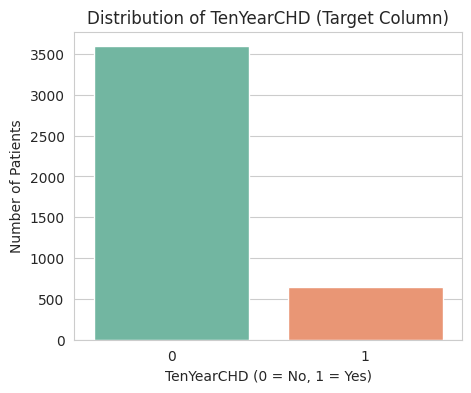

TenYearCHD
0    3594
1     644
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x='TenYearCHD', data=df, palette='Set2')
plt.title("Distribution of TenYearCHD (Target Column)")
plt.xlabel("TenYearCHD (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

print(df['TenYearCHD'].value_counts())


### Age Distribution

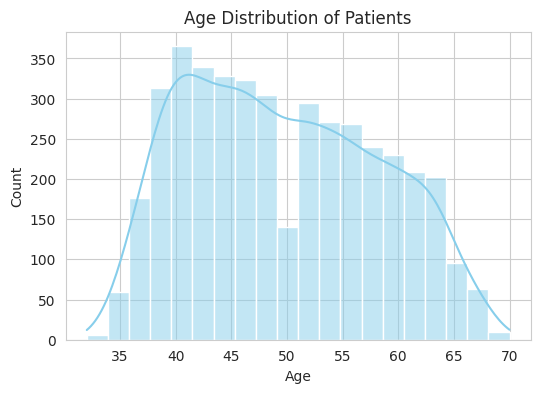

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### Gender vs CHD

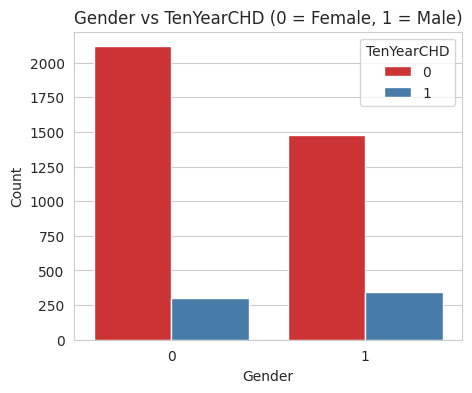

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='male', hue='TenYearCHD', data=df, palette='Set1')
plt.title("Gender vs TenYearCHD (0 = Female, 1 = Male)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


### Smoking vs CHD

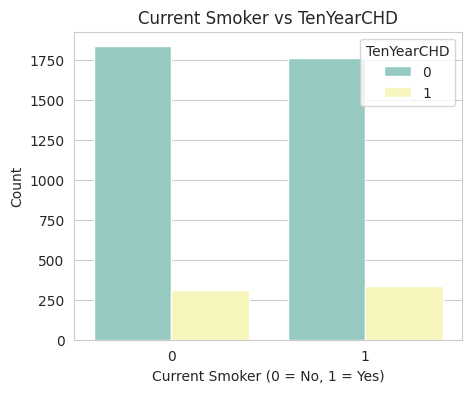

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='currentSmoker', hue='TenYearCHD', data=df, palette='Set3')
plt.title("Current Smoker vs TenYearCHD")
plt.xlabel("Current Smoker (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


### Correlation Heatmap

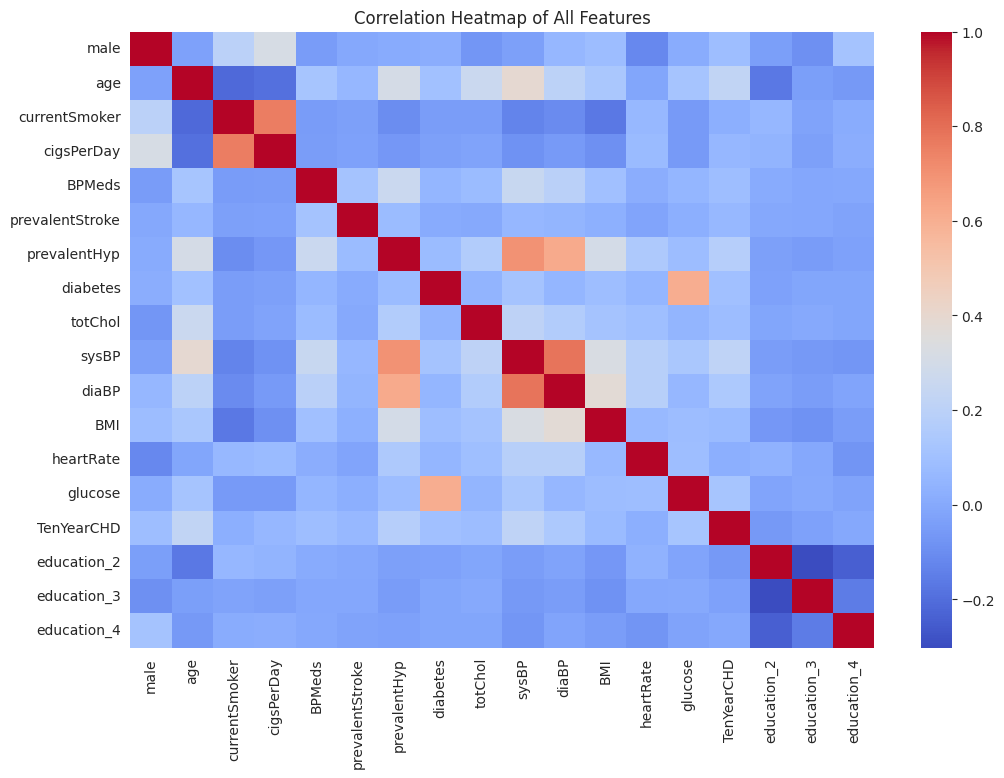

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of All Features")
plt.show()


### Systolic BP vs CHD

/tmp/ipykernel_479/1710468173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TenYearCHD', y='sysBP', data=df, palette='Set2')


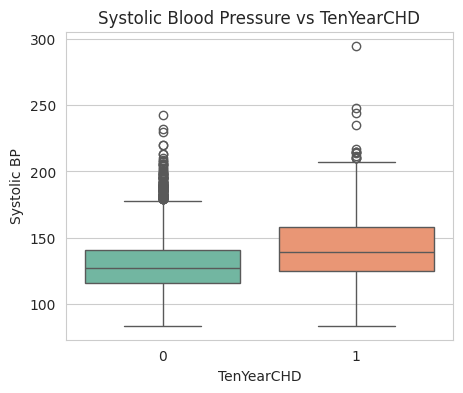

In [14]:
plt.figure(figsize=(5,4))
sns.boxplot(x='TenYearCHD', y='sysBP', data=df, palette='Set2')
plt.title("Systolic Blood Pressure vs TenYearCHD")
plt.xlabel("TenYearCHD")
plt.ylabel("Systolic BP")
plt.show()


## Features and Target

In [15]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (4238, 17)
Shape of y: (4238,)


## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (3390, 17)
Testing set shape: (848, 17)


## Feature Scaling

In [17]:
scaler = StandardScaler()

# Fit the scaler ONLY on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done successfully!")


Feature scaling done successfully!


## Handle Imbalanced Dataset (SMOTE)

In [18]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", y_train_bal.value_counts().to_dict())


Before SMOTE: {0: 2875, 1: 515}
After SMOTE: {0: 2875, 1: 2875}


## Model 1: Logistic Regression

In [19]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_bal, y_train_bal)

# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


### Evaluation

In [20]:
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Accuracy :", round(acc_log, 3))
print("Precision:", round(prec_log, 3))
print("Recall   :", round(rec_log, 3))
print("F1-Score :", round(f1_log, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))


Accuracy : 0.665
Precision: 0.249
Recall   : 0.597
F1-Score : 0.352

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.68      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.67      0.71       848



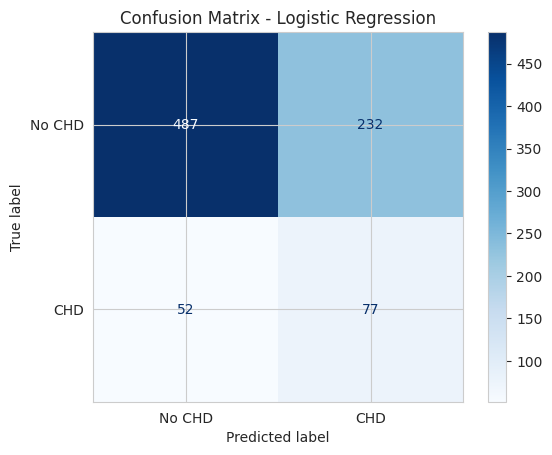

In [21]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No CHD', 'CHD'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


## Model 2: Random Forest

In [22]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


### Evaluation

In [23]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(acc_rf, 3))
print("Precision:", round(prec_rf, 3))
print("Recall   :", round(rec_rf, 3))
print("F1-Score :", round(f1_rf, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Accuracy : 0.724
Precision: 0.244
Recall   : 0.388
F1-Score : 0.299

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.78      0.83       719
           1       0.24      0.39      0.30       129

    accuracy                           0.72       848
   macro avg       0.56      0.59      0.56       848
weighted avg       0.78      0.72      0.75       848



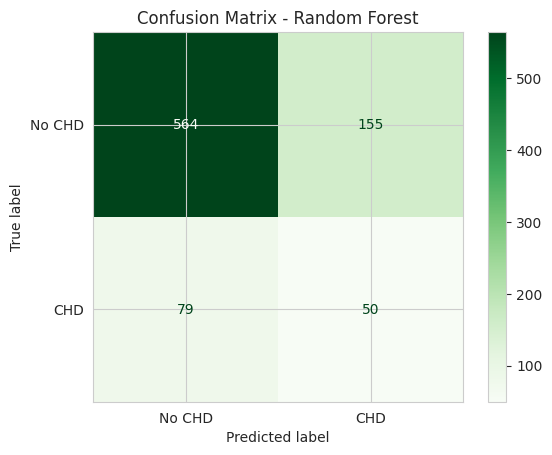

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No CHD', 'CHD'])
disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()


## Feature Importance

/tmp/ipykernel_479/3106992421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


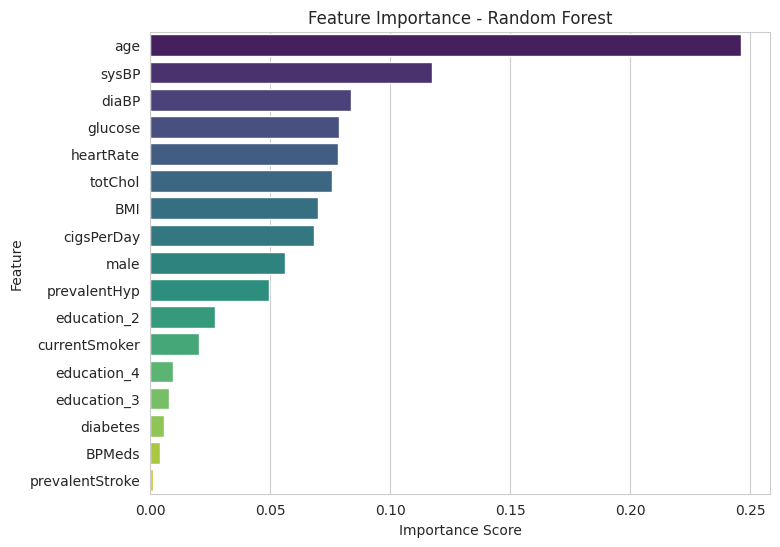

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## Compare Both Models

In [26]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_log, acc_rf],
    'Precision': [prec_log, prec_rf],
    'Recall': [rec_log, rec_rf],
    'F1-Score': [f1_log, f1_rf]
})

results


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.665094,0.249191,0.596899,0.351598
1,Random Forest,0.724057,0.243902,0.387597,0.299401


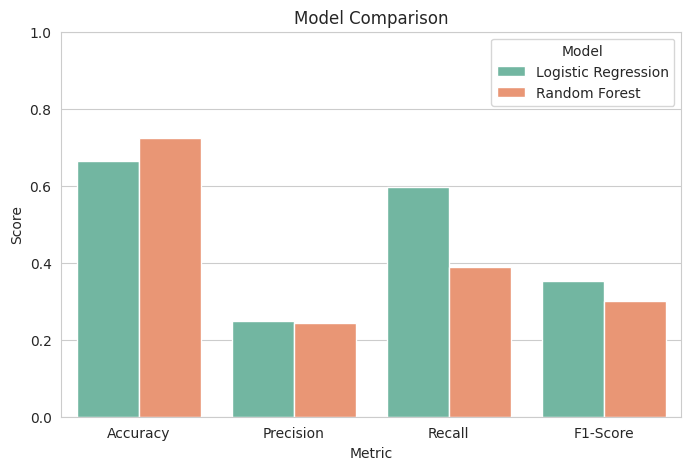

Best model based on Accuracy: Random Forest


In [27]:
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8,5))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='Set2')
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

best_model_name = results.loc[results['Accuracy'].idxmax(), 'Model']
print("Best model based on Accuracy:", best_model_name)


## Conclusion